In [1]:
import warnings

warnings.simplefilter("ignore")
#from altaipony.lcio import from_mast
#from funcs.detrend import custom_detrending, estimate_detrended_noise
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

In [2]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[7].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
#lc2_m = lc2.remove_nans()
lc2_m = lc2.normalize().remove_nans()

In [3]:
x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

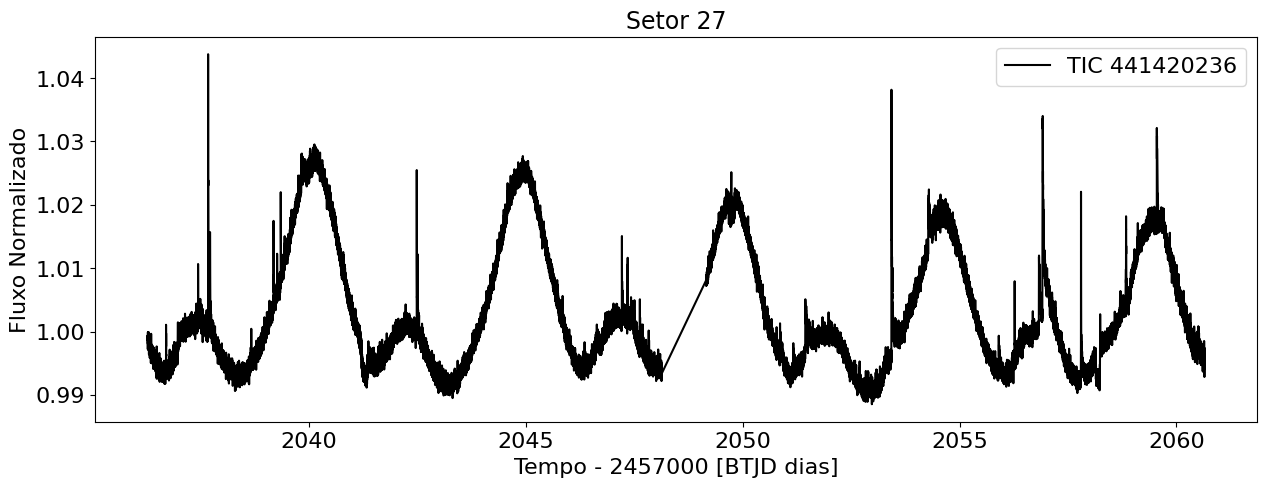

In [4]:
#%matplotlib notebook
plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
labels= ["TIC 441420236"]
ax.set_xlabel('Tempo - 2457000 [BTJD dias]').set_fontsize(16)
ax.set_ylabel('Fluxo Normalizado').set_fontsize(16)  
plt.title('Setor 27').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()

In [5]:
############## Detreding ##############3
vetores = [
    [2036.7054, 2036.71023],
    [2037.4429, 2037.44941],
    [2041.195,2041.387],
    [2037.663,2037.787],
    [2037.6736, 2037.6953],
    [2037.71922, 2037.7435],
    [2039.18134, 2039.1888],
    [2039.26492, 2039.26775],
    [2039.34872, 2039.35791],
    [2039.82051, 2039.84413],
    [2042.48425, 2042.49485],
    [2042.50061, 2042.51093],
    [2047.21325, 2047.2352],
    [2047.34522, 2047.35652],
    [2047.6273,2047.6467],
    [2049.6324,2049.8531],
    [2051.1540,2051.2290],
    [2051.4325,2051.5796],
    [2054.2655,2054.3711],
    [2055.8981,2055.9470],
    [2056.8229,2056.8623],
    [2047.50326, 2047.51074],
    [2047.62795, 2047.63086],
    [2047.83154, 2047.83609],
    [2047.84043, 2047.84221],
    [2049.73685, 2049.7421],
    [2050.78104, 2050.78403],
    [2050.85602, 2050.8691],
    [2050.31549, 2050.31673],
    [2051.44131, 2051.45145],
    [2053.08171, 2053.08283],
    [2053.4107, 2053.6154],
    [2042.4797,2042.5663],
    [2055.90268, 2055.90634],
    [2056.26941, 2056.27345],
    [2056.68717, 2056.70876],
    [2056.82836, 2056.83581],
    [2056.90861, 2056.92518],
    [2057.7945, 2057.9036],
    [2058.24052, 2058.24389],
    [2058.1191,2058.2976],
    [2058.83466, 2058.83466],
    [2059.10883, 2059.11091],
    [2058.803,2058.912],
    [2056.9016,2057.1076],
    [2059.54703, 2059.56109]
]

vetor_true = [False]*len(x2min)


#indices = []
#indices = np.where((x2min>=vetores[0][0]) & (x2min<=vetores[0][1]))

for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)


flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=False, break_tolerance=100, niters=3, sigma=2.5, mask=mascara)
x_detrend = np.ascontiguousarray(flcd.time.value, dtype=np.float64) 
y_detrend = np.ascontiguousarray(flcd.flux, dtype=np.float64)
yerr_detrend= np.ascontiguousarray(flcd.flux_err, dtype=np.float64)



<IPython.core.display.Javascript object>


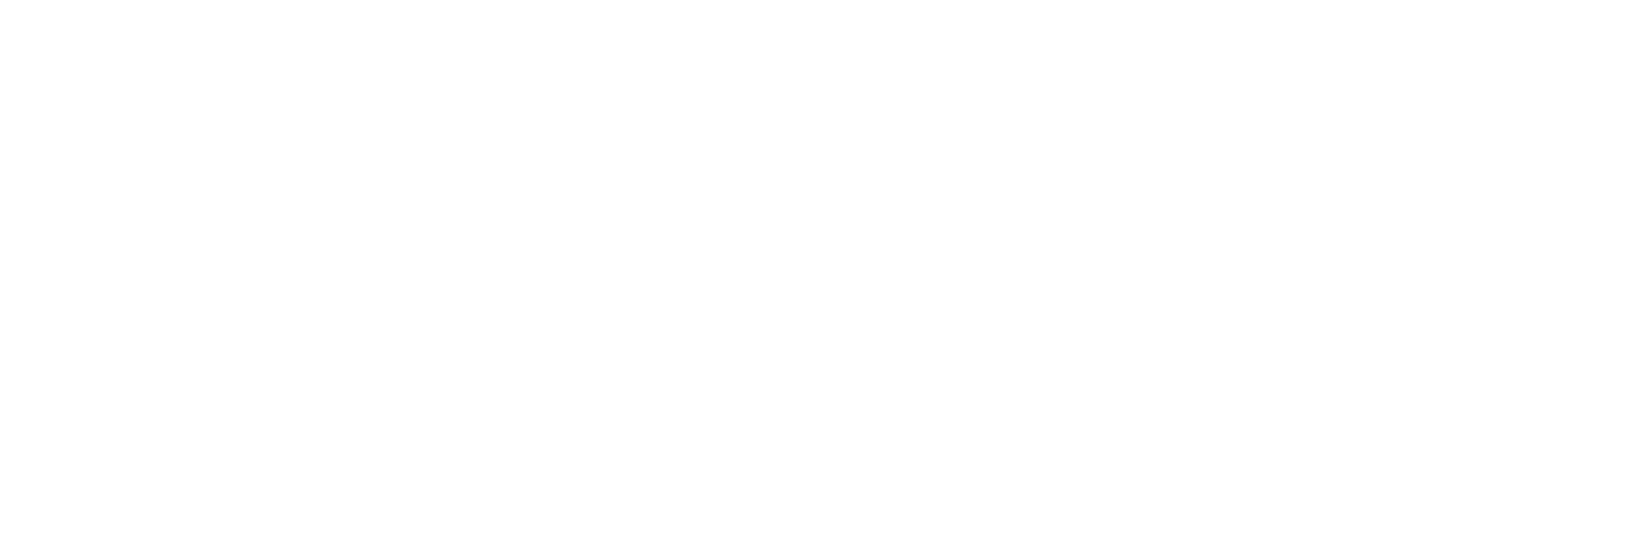

In [6]:
%matplotlib notebook  

fig, ax = plt.subplots(1, 1, figsize=(15, 5))

# Plot dos dados originais
ax.plot(x2min, y2min, 'k-', label='AU Mic')

# Plot da tendência ajustada
ax.plot(x_detrend,y_detrend, linewidth=3, label="Ajuste")

ax.set_title('Setor 27', fontsize=17)
ax.set_ylabel("Fluxo Normalizado")
ax.set_xlabel("Tempo - 2457000 [BTJD dias]")

# Adicione outras configurações do gráfico, se necessário

ax.legend()
plt.show()

In [7]:
flcd.to_fits(path='lightcurve_new.fits', overwrite=True)

In [8]:
#Transformando os arquivos em fits e salvando 
from astropy.io import fits
hdu = fits.open('lightcurve_new.fits')
type(hdu)

from astropy.table import Table
dat = Table.read('lightcurve_new.fits', format='fits')
df = dat.to_pandas()

In [9]:
print(df.isna().sum()) #Contagem de dados nans nas colunas
df = df.dropna(subset=['TIME']) 
df = df.dropna(subset=['QUALITY']) # retirar valores 
#print(df.isna().sum())
df.drop(df[df.QUALITY>0].index ,inplace=True) # exclui linhas onde flag com raios cósmicos

TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64


In [25]:
%matplotlib inline
time=df["TIME"] # tempo
flux=df["FLUX"] #flux
s=df["QUALITY"] # sap_quality
sf  = df['QUALITY'] > 1 # filtra flag com valores maiores que 1 ou seja flag 128 e 8192, são raios cósmicos
#from scipy.signal import savgol_filter
rf = np.mean(flux)/np.mean(flux) #Fluxo relativo

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


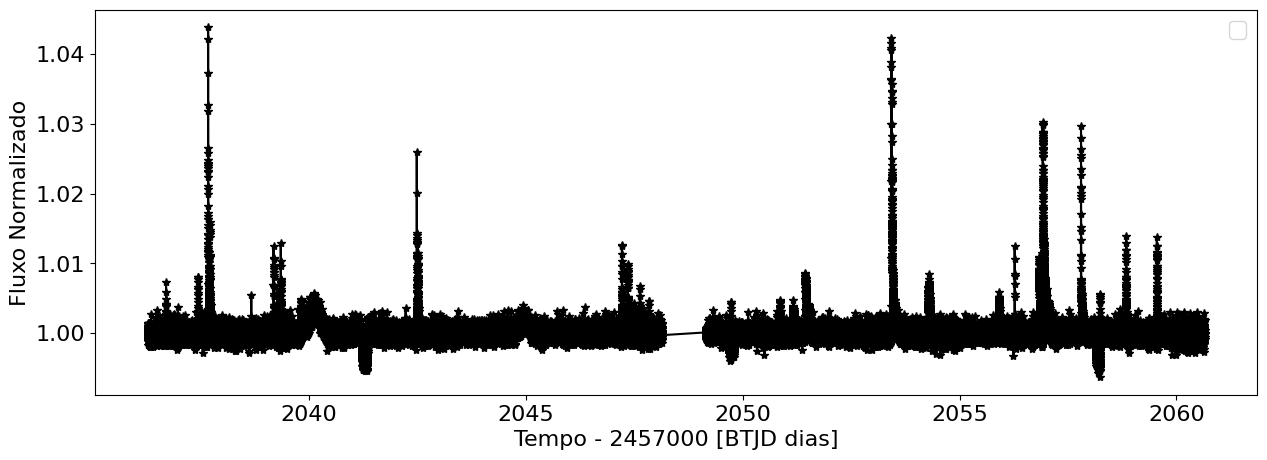

In [26]:
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(time,flux, 'k*-')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()

<IPython.core.display.Javascript object>


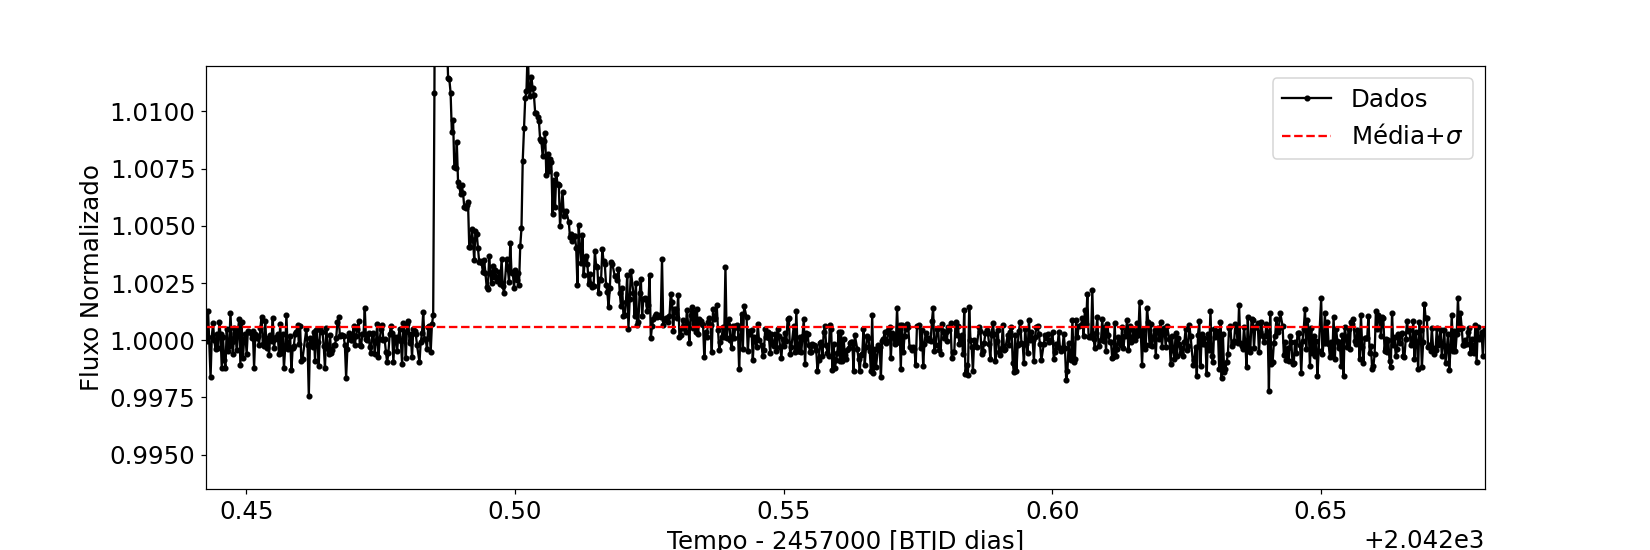

In [54]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+(1/3*np.array(np.std(flux))), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()

<IPython.core.display.Javascript object>


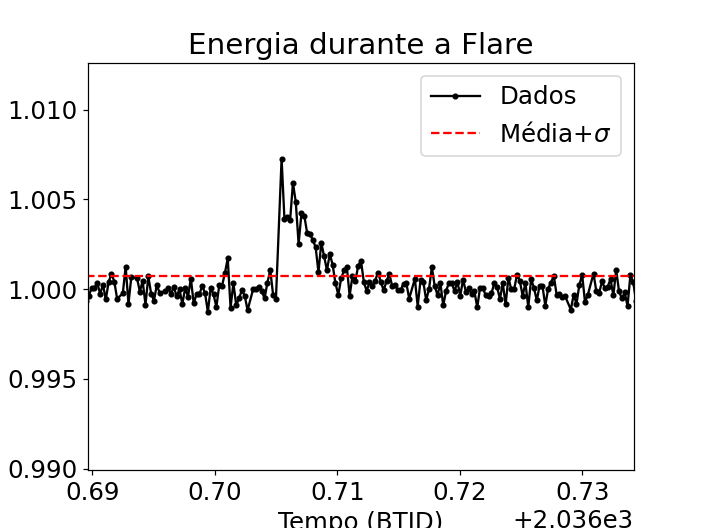

1.0002136


In [65]:

import numpy as np
import matplotlib.pyplot as plt

#
y_mean = np.mean(flux)
desvio_padrao = np.std(flux)


# Cria um array com o mesmo valor de y_mean + desvio_padrao para cada elemento em time
y_mean_plus_std = np.full_like(time, y_mean + 1/3*desvio_padrao)

# Cria o gráfico
fig, ax = plt.subplots()
data_line = ax.plot(time, flux, label='Dados', marker='.', color='black')
mean_line = ax.plot(time, y_mean_plus_std, label='Média+$\sigma$', linestyle='--', color='red')

plt.legend()
plt.show()

print(y_mean)

<IPython.core.display.Javascript object>


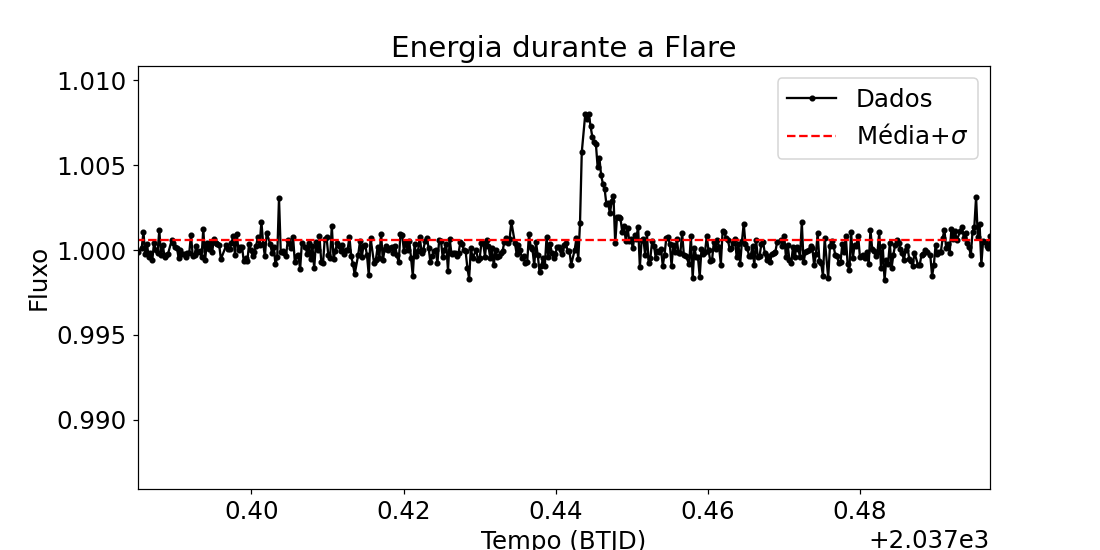

[1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576, 1.0000576

In [91]:
%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)
#print(y_mean)
fig,ax = plt.subplots(1,1,figsize=(10,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+1/3*np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')
print(y_mean)
#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()

In [92]:
# Valores de início e término da flare (substitua pelos valores desejados)
start_input =2047.21289574
stop_input =  2047.24318

def ener_flare(start, stop, time, flux):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i] >= start and time[i] <= stop:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])

    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    return flux_flare, tempo_flare

# Chamada da função ener_flare com os dados de exemplo
flux_flare, tempo_flare = ener_flare(start_input, stop_input, time, flux)
print(flux_flare)
print(tempo_flare)
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare, flux_flare, 'ro')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

[1.0000123  1.0016118  1.0030869  1.0039397  1.0053757  1.0052251
 1.0084622  1.0095642  1.0096091  1.0124799  1.0125711  1.0113469
 1.0103121  1.0087085  1.0077469  1.006548   1.0063629  1.005851
 1.005955   1.0053389  1.0055107  1.0059414  1.0057881  1.0051923
 1.0039812  1.0048318  1.0033017  1.0054564  1.0038109  1.0045545
 1.0038044  1.0035571  1.0038348  1.0038661  1.0031258  1.0035187
 1.0032635  1.0037255  1.0035304  1.0027555  1.0036585  1.0034578
 1.0040638  1.0021207  1.0025753  1.0030797  1.002851   1.0029657
 1.0027173  1.0023978  1.0034585  1.0025907  1.0030128  1.0027366
 1.001082   1.0033848  1.0020825  1.0013317  1.002206   1.0024576
 1.0016556  1.0024042  1.0010484  1.002498   1.0019252  1.0018674
 1.0028452  1.0018796  1.0035958  1.0027142  1.0015261  1.0017896
 1.0015122  1.0023634  1.0017799  1.002572   1.0013227  1.0014406
 1.0016271  1.0015616  1.0010908  1.0018561  1.0023822  1.0007764
 1.002067   1.0013304  1.001586   1.0023808  1.0016961  1.0016068
 1.0019004 

In [17]:

flux_flare1 = np.array(flux_flare)
tempo_flare1 = np.array(tempo_flare) 

# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flare1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare =  flux_flare1 - 1


# Integral
Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flare1*86400) #erg



print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare1, amplitude_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

NameError: name 'raio' is not defined

In [ ]:
##### Alguns dados básicos##################
fl129=pd.read_csv('flares_setor1.csv') #lendo os flares 
tess_f = pd.read_csv('tess_functionx1.csv') #lendo os arquivos da função de resposta
tf = pd.DataFrame(tess_f)
df = pd.DataFrame(fl129)

nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response

In [ ]:
########## Constantes necessárias para o calculo da explosão#########

#Energia da flare
from PyAstronomy.pyasl import planck

#Mudança nm para cm e metro 
nm_metros = nm*(1e-9) #de nm para metros 
nm_cm = nm*(1e-7) #de nm para cm 


#Constantes importantes 
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4


###########################
#Calculo da função de Planck
# Essa função (Bs=planck(Teff,lam=nm_metros)) da em [W/(m**2 m)] então
Bs=planck(Teff,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)